In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

import torch

#Make sure to path to wherever sherlock is located
sys.path.append('../..')
import sherlock as slk

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
slk.configs.show()
slk.configs.set_config('ntc_label', 'non-targeting')
print('\n')
slk.configs.show()
slk.configs.reset_config()
slk.configs.get_config('ntc_label')

ntc_label       = NTC
pert_key        = pert
treatment_key   = treatment
untreated_label = untreated


ntc_label       = non-targeting
pert_key        = pert
treatment_key   = treatment
untreated_label = untreated


'NTC'

In [4]:
data = slk.datasets.replogle()

'''Alternatively for your own data:
data = sc.read_h5ad(PATH_TO_YOUR_DATA)
slk_prepare_data(data, pert_key=PERT_KEY, ntc_label=NTC_LABEL, treatment_key=TREATMENT_KEY|None, inplace=True)
'''

'Alternatively for your own data:\ndata = sc.read_h5ad(PATH_TO_YOUR_DATA)\nslk_prepare_data(data, pert_key=PERT_KEY, ntc_label=NTC_LABEL, treatment_key=TREATMENT_KEY|None, inplace=True)\n'

In [5]:
perturbations = set(np.unique(data.obs[slk.configs.get_config('pert_key')].values))
print("Perturbations:", len(perturbations))

pathways = []
for pathway in data.uns['pathways'].values():
    pathways.append(set(pathway))
sum([len(pathways[i]) for i in range(len(pathways))])
print("Pathways:", len(pathways))

overlap = any(len(set(pathways[i]) & set(pathways[j])) > 0 for i in range(len(pathways)) for j in range(i + 1, len(pathways)))
print("Overlap exists between pathways:" if overlap else "No overlap between pathways.")

Perturbations: 682
Pathways: 8
No overlap between pathways.


In [6]:
slk.pp.treat_effect(
    data,
    label_col = 'pert',
    control_label = 'NTC',
    method = "perturbseq",
    inplace=True,
    key='treat_effect'
)

100%|██████████| 681/681 [00:08<00:00, 77.51it/s]


Training VAE on cuda …


Epochs:   0%|          | 0/500 [00:00<?, ?it/s]

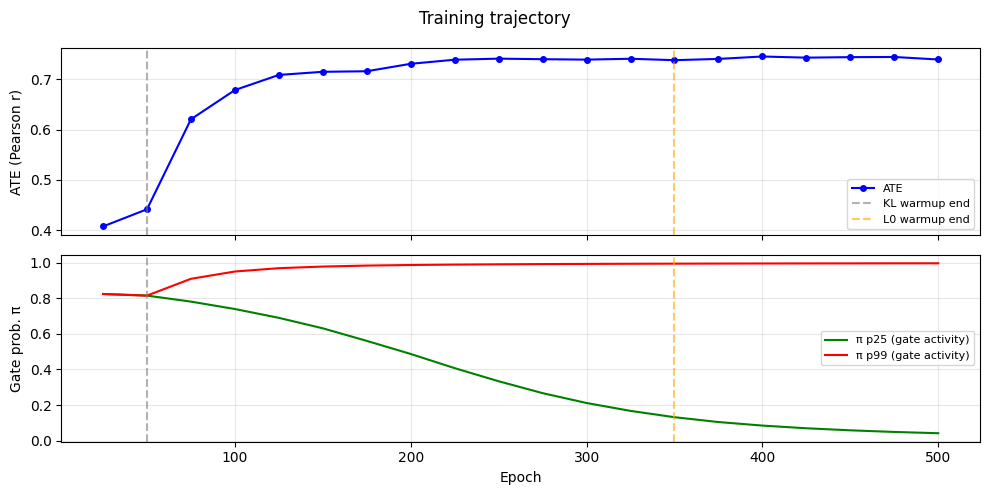

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = slk.tl.run_single(data, 
                            # tau_end=0.3,
                            # cov_lambda=0,
                            # H_lambda=0,
                            # gate_row_repulsion_lambda=0,
                            l0_lambda=1e-1,
                            num_epochs=500,
                            ce_lambda=20.,
                            n_epochs_l0_warmup=300,
                            debug=True,
                            use_de_align_loss=False,
                            de_align_exclude=[], 
                            use_go_prior=False,
                            validate_every=25, batch_size=4096, shuffle=True, num_workers=9, device=device)

In [9]:
model = results['model']

In [10]:
slk.tl.save_results(results, '../results/replogle_model.pth')

In [11]:
model = slk.tl.load_results('../results/replogle_model.pth')

In [8]:
model = slk.tl.load_results('./results/benchmarking/models/sherlock/best.pth')

In [9]:
slk.tl.eval_single(model, data, obsm_key="z", uns_key="results")

KeyError: 'sigma_fac'

In [ ]:
data.uns['results'].keys()

dict_keys(['z_corr', 'perts', 'rho_corr', 'rho_perts', 'rho_embed', 'acc', 'z_rho_corr', 'W', 'counterfactual_effect_size', 'condition_perturbation_interaction', 'conditions'])

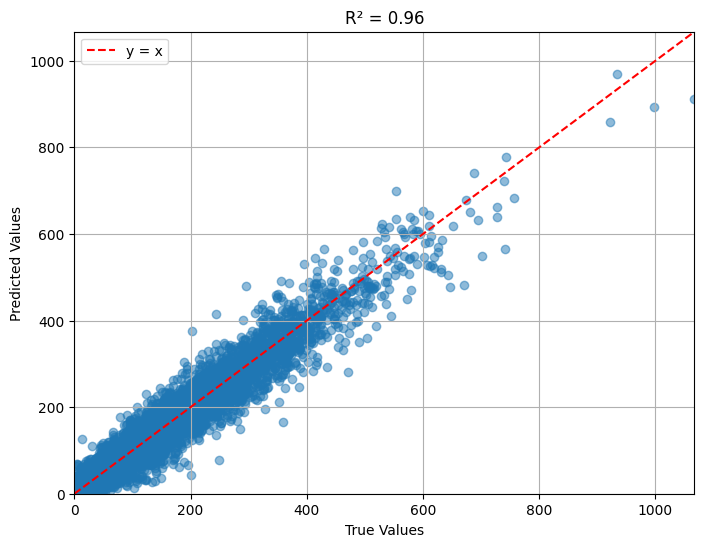

In [13]:
slk.pl.plot_r2(data)

/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


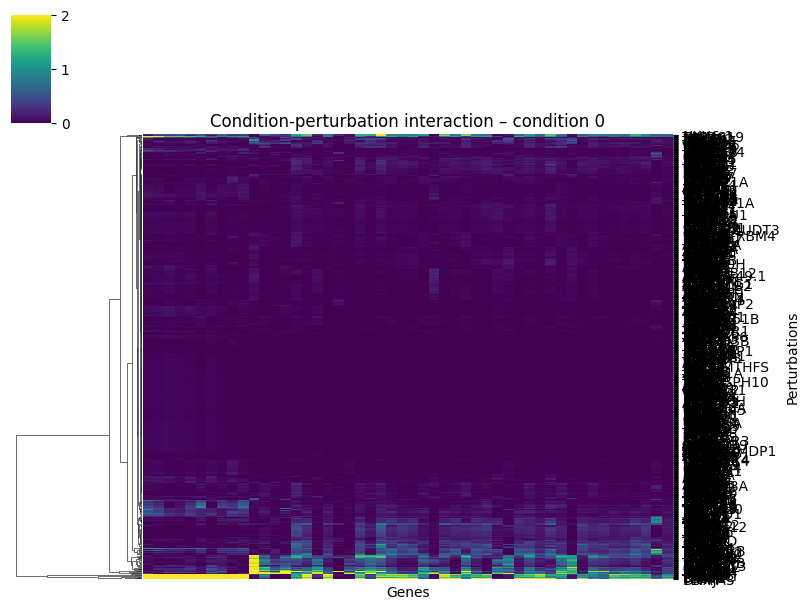

In [20]:
slk.pl.plot_ev(data, cmax=2, top_n=50)

In [21]:
slk.tl.ev_sig(data)

In [22]:
# Useful dataframe that plot_ev_sig uses internally
slk.pl.make_ev_long_df(data, cond_idx=0, uns_key="results")

,pert,gene,ev,pval,qval
0,AAR2,NOC2L,0.000243,0.622303,0.785270
1,AAR2,ISG15,0.000501,0.421702,0.785270
2,AAR2,AURKAIP1,0.000050,0.755364,0.785270
3,AAR2,ATAD3A,0.001012,0.114217,0.508822
4,AAR2,RPL22,0.000172,0.673888,0.785270
...,...,...,...,...,...
806980,ZNHIT6,MT-ND4L,0.002827,0.723780,0.774467
806981,ZNHIT6,MT-ND4,0.002058,0.738092,0.774467
806982,ZNHIT6,MT-ND5,0.005201,0.677284,0.774467
806983,ZNHIT6,MT-ND6,0.000005,0.774380,0.774467


In [23]:
slk.pl.plot_ev_sig(
    data,
    cond_idx=0,
    uns_key="results",
    alpha=0.05,
    top_n_genes=10,
    min_sig_genes=3,
    cluster_rows=True,
    cluster_cols=False,
    use_clustermap=True,
)

/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


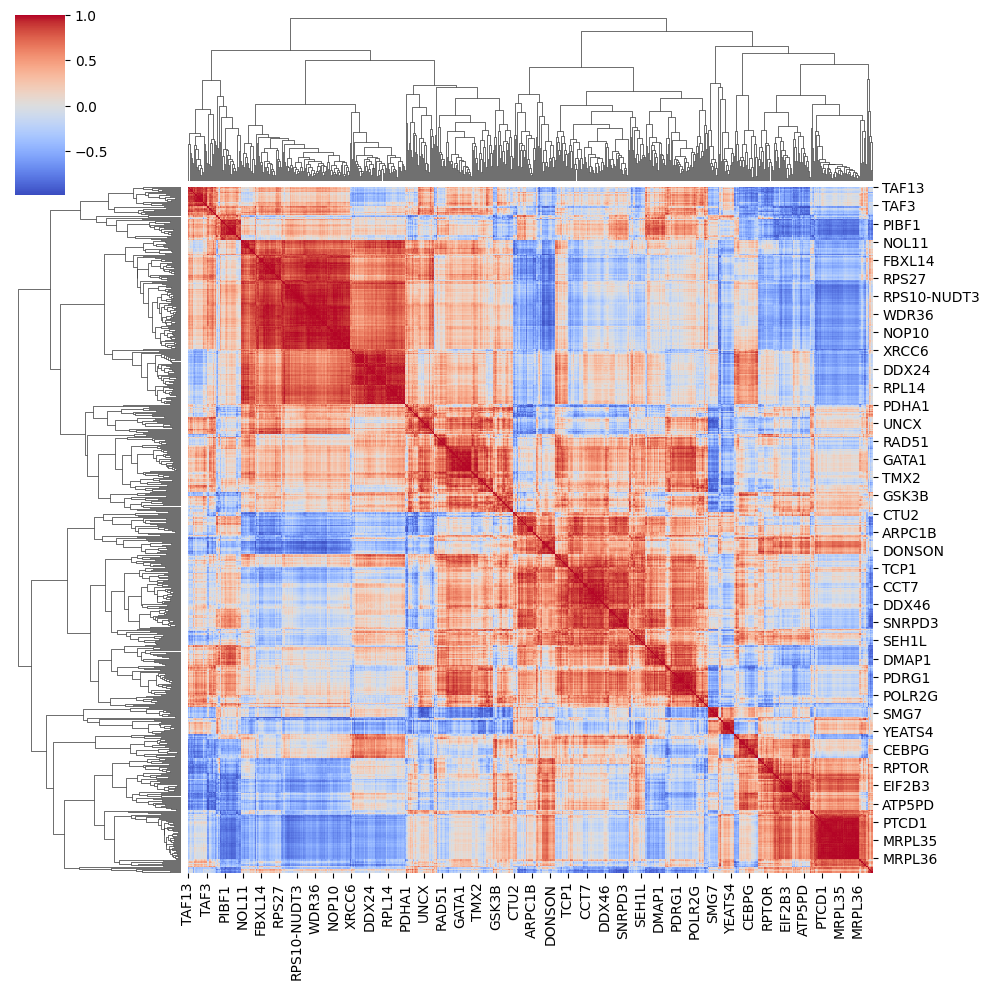

In [11]:
slk.pl.plot_corr(data)

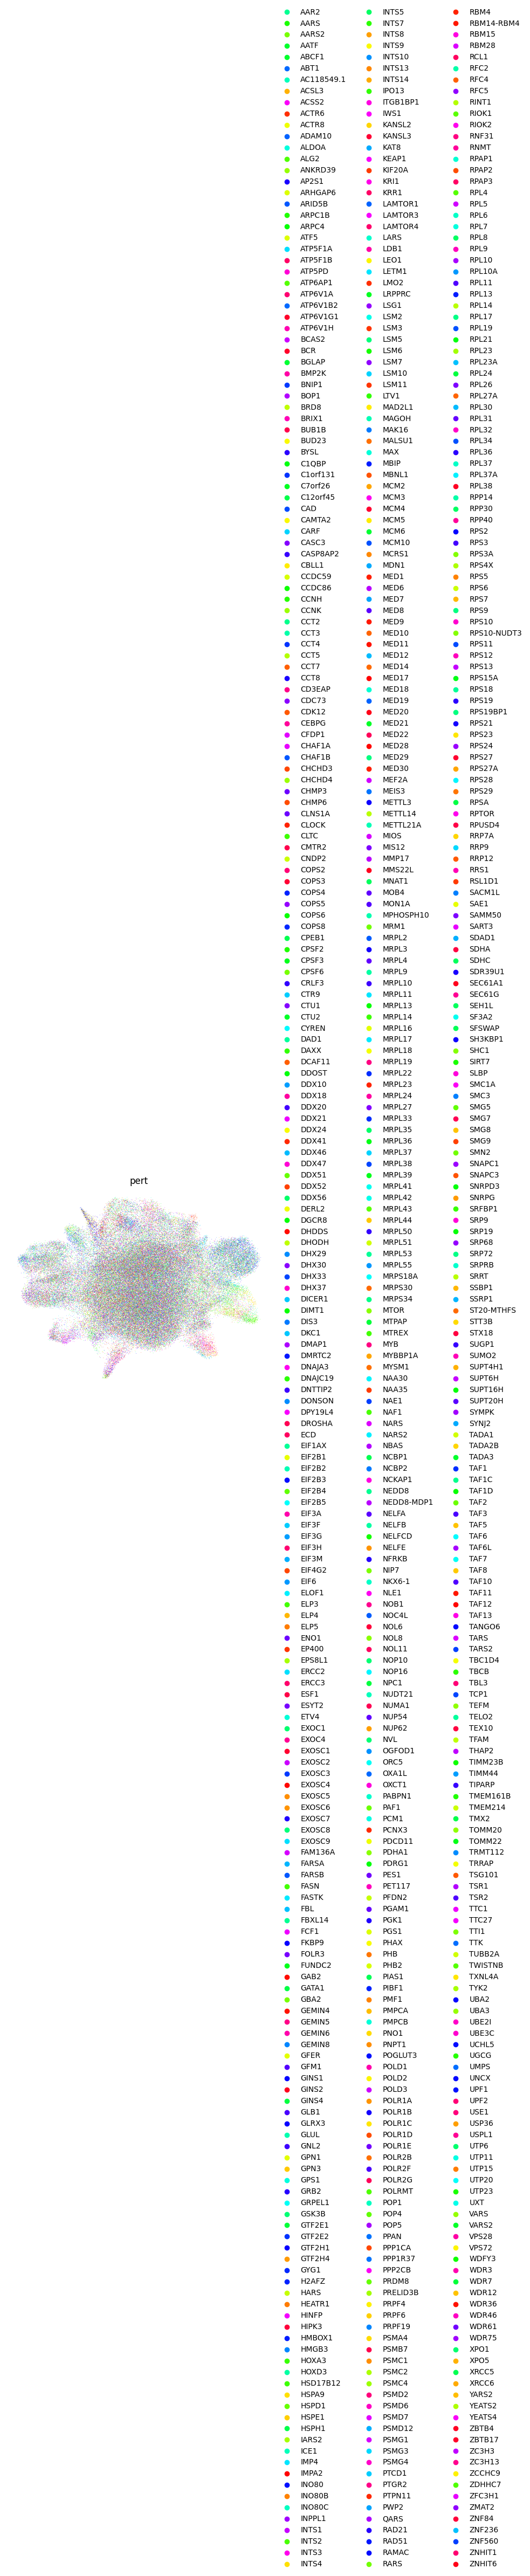

In [12]:
p_key = slk.configs.get_config('pert_key')
NTC = slk.configs.get_config('ntc_label')

sub = data[data.obs[p_key] != NTC]

sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

import random
n_cats = sub.obs[p_key].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub, color='pert', palette=palette, frameon=False)

In [28]:
zrc = data.uns['results']['z_rho_corr']

print(f"Spearman ρ = {zrc['spearman_r']:.3f}  (p = {zrc['spearman_p']:.1e})")
print(f" Pearson  r = {zrc['pearson_r']:.3f}  (p = {zrc['pearson_p']:.1e})") 

Spearman ρ = 0.762  (p = 0.0e+00)
 Pearson  r = 0.778  (p = 0.0e+00)


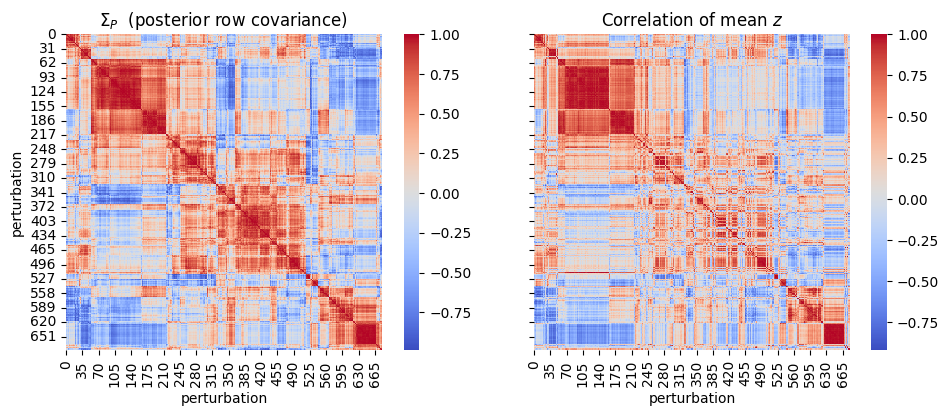

In [14]:
slk.pl.plot_zcorr(data)

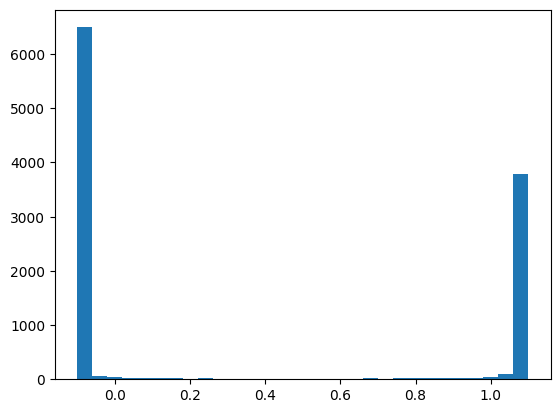

In [15]:
W = data.uns['results']['W']
plt.hist(W.flatten(), bins=30)
plt.show()

<Axes: >

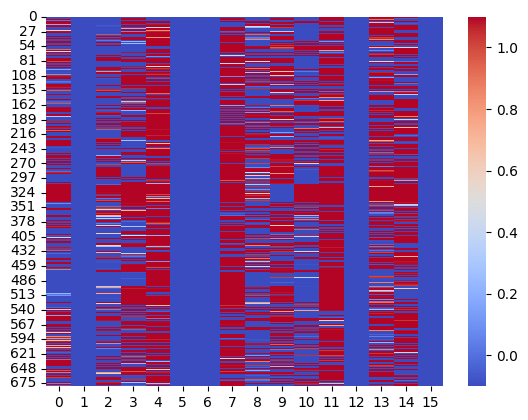

In [16]:
W_bin = (W > 0.5).astype(float)
sns.heatmap(W, cmap="coolwarm")

In [17]:
p_key = slk.configs.get_config('pert_key')

dataset = slk.tl.PerturbMatchingDataset(data)
n_perts    = len(dataset.perturbation_dict)
latent_dim = data.obsm['z'].shape[1]

z_bar = np.zeros((n_perts, latent_dim))
for pert, pidx in dataset.perturbation_dict.items():
    mask = data.obs[p_key] == pert
    if mask.any():
        z_bar[pidx] = data.obsm['z'][mask].mean(0)

C = np.corrcoef(z_bar)

In [18]:
C = data.uns['results']['z_corr']

#Specific subsetting for replogle. Otherwise just use C directly
all_genes = [gene for genes in data.uns['pathways'].values() for gene in genes]
dataset = slk.tl.PerturbMatchingDataset(data)
gene_ids = [dataset.perturbation_dict[g] for g in all_genes]
cov_subset = C[np.ix_(gene_ids, gene_ids)].clip(-1, 1)

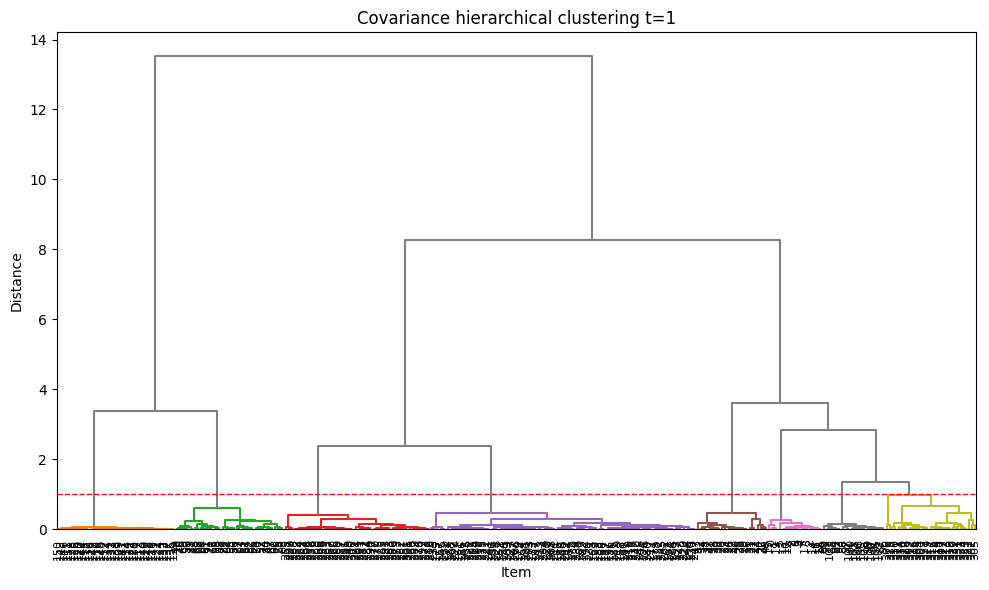

In [29]:
groups = slk.tl.cluster_rho(data, t=1, criterion='distance', method='ward', rho_corr=cov_subset, show=True)

In [30]:
#for a non subsetted data, pass in genes corresponding to idx ie dataset.perturbation_dict.keys()
named_groups = slk.tl.group2name(groups, all_genes)
named_groups

,group
ZC3H3,6
ZFC3H1,6
CAMTA2,6
DHX29,6
DIS3,6
...,...
SNRPG,8
TIPARP,8
TTC27,8
TXNL4A,8


## From here on out it is validation of replogle

In [31]:
from collections import Counter

# Flatten all genes from all pathways
#all_genes = [gene for genes in data.uns['pathways'].values() for gene in genes]

# Count how many times each gene appears
gene_counts = Counter(all_genes)

# Find genes that appear in more than one pathway
shared_genes = [gene for gene, count in gene_counts.items() if count > 1]

if shared_genes:
    print(f"⚠️ {len(shared_genes)} genes are shared across pathways:")
    print(shared_genes[:20])  # show first 20 for inspection
else:
    print("✅ Each gene appears in exactly one pathway.")


#pert df
pathway_genes = np.concatenate([i for i in list(data.uns['pathways'].values())])
pathway_genes = pathway_genes[pathway_genes != 'LSM5']
print(len(pathway_genes))
print(len(all_genes))
perts = pd.DataFrame(groups, index=all_genes, columns=['cluster'])
perts = perts.loc[pathway_genes]

#pathway df
gene_to_pathway = {
    gene: pathway
    for pathway, genes in data.uns['pathways'].items()
    for gene in genes if gene != 'LSM5'
}
pathway_df = pd.DataFrame.from_dict(gene_to_pathway, orient="index", columns=["cluster"])


perts = perts.drop(shared_genes, errors="ignore")
pathway_df = pathway_df.drop(shared_genes, errors="ignore")

print("After removal:")
print("perts size     :", perts.shape)
print("pathway_df size:", pathway_df.shape)

✅ Each gene appears in exactly one pathway.
335
335
After removal:
perts size     : (335, 1)
pathway_df size: (335, 1)


In [32]:
pathway_df['gene'] = pathway_df.index.copy()
pathway_df.columns = ['pathway', 'gene']
pathway_df

,pathway,gene
ZC3H3,EXOSOME,ZC3H3
ZFC3H1,EXOSOME,ZFC3H1
CAMTA2,EXOSOME,CAMTA2
DHX29,EXOSOME,DHX29
DIS3,EXOSOME,DIS3
...,...,...
SNRPG,SPLICEOSOME,SNRPG
TIPARP,SPLICEOSOME,TIPARP
TTC27,SPLICEOSOME,TTC27
TXNL4A,SPLICEOSOME,TXNL4A


In [33]:
# Align on the same gene index
perts_aligned = perts.loc[pathway_df.index]

perts_aligned['gene'] = perts_aligned.index.copy()
perts_aligned

,cluster,gene
ZC3H3,6,ZC3H3
ZFC3H1,6,ZFC3H1
CAMTA2,6,CAMTA2
DHX29,6,DHX29
DIS3,6,DIS3
...,...,...
SNRPG,8,SNRPG
TIPARP,8,TIPARP
TTC27,8,TTC27
TXNL4A,8,TXNL4A


In [34]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    adjusted_rand_score, adjusted_mutual_info_score,
    homogeneity_completeness_v_measure, silhouette_score,
    precision_score, recall_score, f1_score,
)
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment
from scipy.stats import hypergeom

try:
    from statsmodels.stats.multitest import multipletests
    _HAS_SM = True
except Exception:
    _HAS_SM = False


def align_and_summarize(
    clusters_df: pd.DataFrame,
    pathways_df: pd.DataFrame,
    gene_col: str = "gene",
    cluster_col: str = "cluster",
    pathway_col: str = "pathway",
    min_pathway_size: int = 1,
    gene_embeddings: pd.DataFrame | None = None,  # index=gene, cols=latent dims
):
    # 1) Merge on gene
    df = pd.merge(
        clusters_df[[gene_col, cluster_col]],
        pathways_df[[gene_col, pathway_col]],
        on=gene_col,
        how="inner",
        validate="one_to_one"
    ).dropna(subset=[cluster_col, pathway_col]).copy()

    # Optional: filter tiny pathways to stabilize Hungarian/enrichment
    if min_pathway_size > 1:
        keep_path = df[pathway_col].value_counts()
        keep_path = keep_path[keep_path >= min_pathway_size].index
        df = df[df[pathway_col].isin(keep_path)].copy()

    # Cast to string for safe indexing
    y_true = df[pathway_col].astype(str).values
    y_pred = df[cluster_col].astype(str).values
    true_labels = np.unique(y_true)
    pred_labels = np.unique(y_pred)

    # 2) Contingency (rows=pathways, cols=clusters)
    C = pd.crosstab(df[pathway_col].astype(str), df[cluster_col].astype(str))
    contingency_df = C.reindex(index=true_labels, columns=pred_labels, fill_value=0)

    # 3) Hungarian alignment to maximize correct assignments (sum of diagonal)
    M = contingency_df.values
    row_ind, col_ind = linear_sum_assignment(M.max() - M)  # maximize
    mapping = {pred_labels[j]: true_labels[i] for i, j in zip(row_ind, col_ind)}

    # Assign any unmapped clusters to their majority pathway (fallback)
    for cl in pred_labels:
        if cl not in mapping:
            cl_mask = df[cluster_col].astype(str) == cl
            if cl_mask.any():
                mapping[cl] = df.loc[cl_mask, pathway_col].mode().iloc[0]

    # 4) Remap clusters → pathways and compute metrics
    mapped = np.array([mapping.get(cl, None) for cl in y_pred], dtype=object)
    is_match = mapped == y_true
    accuracy = float(is_match.mean())

    # Global F1 / precision / recall (macro-averaged over pathways)
    precision = precision_score(y_true, mapped, average="macro", zero_division=0)
    recall    = recall_score(y_true, mapped, average="macro", zero_division=0)
    f1        = f1_score(y_true, mapped, average="macro", zero_division=0)

    # Label-based external clustering metrics
    ari = adjusted_rand_score(y_true, y_pred)
    ami = adjusted_mutual_info_score(y_true, y_pred)
    homogeneity, completeness, v_measure = homogeneity_completeness_v_measure(y_true, y_pred)

    # Silhouette score (requires embeddings)
    sil = None
    if gene_embeddings is not None:
        genes_in_df = df[gene_col].values
        emb = gene_embeddings.loc[genes_in_df].values
        sil = silhouette_score(emb, mapped, metric='euclidean')

    # 5) Per-cluster purity & recall
    purity_rows = []
    for cl, g in df.groupby(cluster_col):
        majority = g[pathway_col].mode().iat[0]
        purity = (g[pathway_col] == majority).mean()
        pathway_total = (df[pathway_col] == majority).sum()
        recall_cl = (g[pathway_col] == majority).sum() / pathway_total
        purity_rows.append({
            "cluster": str(cl),
            "size": len(g),
            "mapped_pathway": mapping.get(str(cl), None),
            "purity": purity,
            "recall": recall_cl,
        })
    purity_df = pd.DataFrame(purity_rows).sort_values("cluster").set_index("cluster")

    # 6) Normalized contingency for plotting
    contingency = contingency_df.copy()
    contingency_row_norm = contingency.div(contingency.sum(axis=1).replace(0, np.nan), axis=0)
    contingency_col_norm = contingency.div(contingency.sum(axis=0).replace(0, np.nan), axis=1)

    # 7) Pathway↔cluster enrichment (hypergeometric with FDR)
    N = len(df)
    path_sizes = contingency.sum(axis=1)
    cl_sizes = contingency.sum(axis=0)
    records = []
    for p in contingency.index:
        K = int(path_sizes.loc[p])
        for c in contingency.columns:
            n = int(cl_sizes.loc[c])
            k = int(contingency.loc[p, c])
            pval = hypergeom.sf(k - 1, N, K, n) if k > 0 else 1.0
            records.append({"pathway": p, "cluster": c, "k": k, "K": K, "n": n, "N": N, "pval": float(pval)})

    enrich_df = pd.DataFrame(records)
    if _HAS_SM and len(enrich_df) > 0:
        enrich_df["qval"] = multipletests(enrich_df["pval"].values, method="fdr_bh")[1]
    else:
        m = max(len(enrich_df), 1)
        enrich_df["qval"] = np.minimum(enrich_df["pval"] * m, 1.0)

    with np.errstate(divide="ignore"):
        enrich_df["neglog10q"] = -np.log10(np.clip(enrich_df["qval"].values, 1e-300, 1.0))

    # 8) Attach mapped labels into the merged table
    df["mapped_pathway"] = mapped
    df["is_match"] = is_match

    return {
        "merged": df[[gene_col, cluster_col, pathway_col, "mapped_pathway", "is_match"]].rename(
            columns={gene_col: "gene", cluster_col: "cluster", pathway_col: "pathway"}
        ),
        "mapping": mapping,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "ari": ari,
        "ami": ami,
        "homogeneity": homogeneity,
        "completeness": completeness,
        "v_measure": v_measure,
        "silhouette": sil,
        "purity_df": purity_df,
        "contingency": contingency,
        "contingency_row_norm": contingency_row_norm,
        "contingency_col_norm": contingency_col_norm,
        "enrichment": enrich_df,
    }

In [35]:
gene_embeddings = pd.DataFrame(
    z_bar[gene_ids],
    index=all_genes,
)

results = align_and_summarize(
    clusters_df=perts_aligned,          # gene↦cluster from covariance HC
    pathways_df=pathway_df,             # gene↦pathway ground truth
    gene_col="gene",
    cluster_col="cluster",
    pathway_col="pathway",
    min_pathway_size=1,                 # optional: filter tiny pathways
    gene_embeddings=gene_embeddings,
)

print("Best cluster→pathway mapping:")
for cl, pw in results["mapping"].items():
    print(f"  {cl} → {pw}")

print(f"\nGlobal alignment accuracy: {results['accuracy']:.3f}")
print(f"Precision: {results['precision']:.3f} | Recall: {results['recall']:.3f} | F1: {results['f1']:.3f}")
print(f"ARI: {results['ari']:.3f} | AMI: {results['ami']:.3f}")
print(f"Homogeneity: {results['homogeneity']:.3f} | Completeness: {results['completeness']:.3f} | V-measure: {results['v_measure']:.3f}")
print(f"Silhouette:  {results['silhouette']:.3f}")

print("\nPer-cluster purity:")
print(results["purity_df"])

Best cluster→pathway mapping:
  6 → EXOSOME
  5 → MEDIATOR_COMPLEX
  2 → MT_PROTEIN_TRANSLOCATION
  7 → NUCLEOTIDE_EXCISION_REPAIR
  1 → S39_RIBOSOMAL_UNIT
  4 → S40_RIBOSOMAL_UNIT
  3 → S60_RIBOSOMAL_UNIT
  8 → SPLICEOSOME

Global alignment accuracy: 1.000
Precision: 1.000 | Recall: 1.000 | F1: 1.000
ARI: 1.000 | AMI: 1.000
Homogeneity: 1.000 | Completeness: 1.000 | V-measure: 1.000
Silhouette:  0.439

Per-cluster purity:
         size              mapped_pathway  purity  recall
cluster                                                  
1          43          S39_RIBOSOMAL_UNIT     1.0     1.0
2          40    MT_PROTEIN_TRANSLOCATION     1.0     1.0
3          53          S60_RIBOSOMAL_UNIT     1.0     1.0
4          97          S40_RIBOSOMAL_UNIT     1.0     1.0
5          26            MEDIATOR_COMPLEX     1.0     1.0
6          20                     EXOSOME     1.0     1.0
7          23  NUCLEOTIDE_EXCISION_REPAIR     1.0     1.0
8          33                 SPLICEOSOME     1.0  

In [26]:
results_df = results['merged']
clustered_genes = results_df["gene"].unique()

z_sub = sub[sub.obs["pert"].isin(clustered_genes)].copy()
sc.pp.neighbors(z_sub, use_rep='z')
sc.tl.umap(z_sub)

/var/tmp/ipykernel_3882570/579651866.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(all_cats))  # any qualitative map works


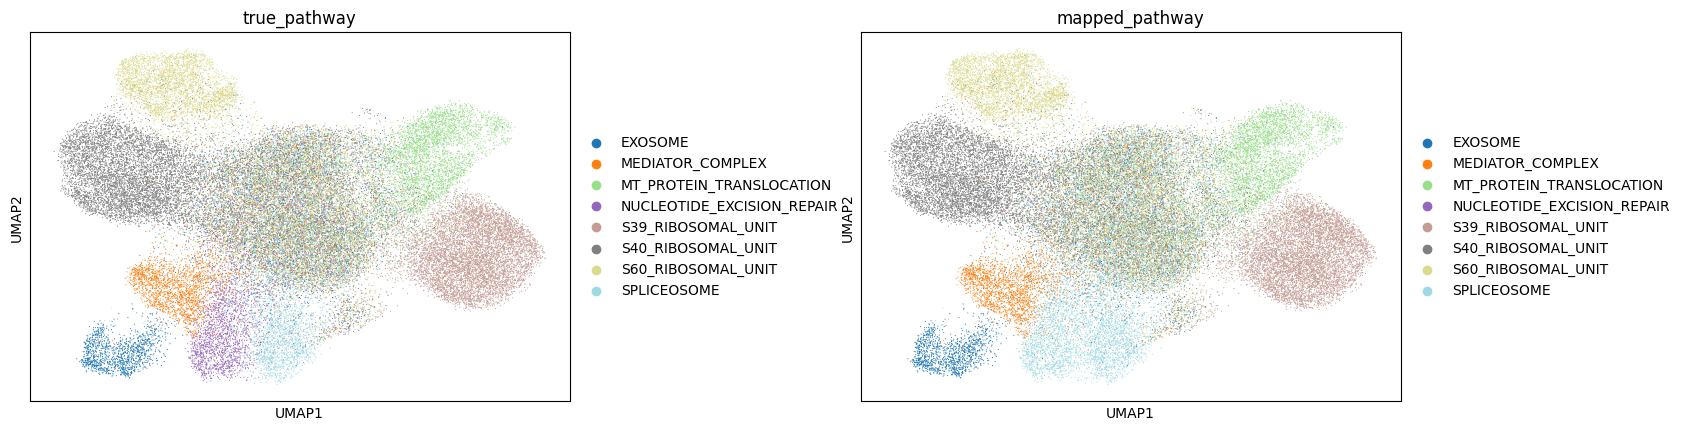

In [27]:
import numpy as np
import pandas as pd
from matplotlib.colors import to_hex
import matplotlib.pyplot as plt

gene_to_true   = dict(zip(results_df["gene"], results_df["pathway"]))
gene_to_mapped = dict(zip(results_df["gene"], results_df["mapped_pathway"]))

z_sub.obs["true_pathway"]   = z_sub.obs["pert"].map(gene_to_true)
z_sub.obs["mapped_pathway"] = z_sub.obs["pert"].map(gene_to_mapped)

# Drop NA mapped rows
z_sub = z_sub[z_sub.obs["mapped_pathway"].notna() & (z_sub.obs["mapped_pathway"] != "NA")].copy()

# --- NEW: enforce identical palettes for both columns ---
# 1) Make both columns categorical with the SAME category set & order
true_vals   = pd.Index(z_sub.obs["true_pathway"].dropna().unique().astype(str))
mapped_vals = pd.Index(z_sub.obs["mapped_pathway"].dropna().unique().astype(str))
all_cats = pd.Index(np.unique(true_vals.union(mapped_vals)))  # sorted union

cat_dtype = pd.api.types.CategoricalDtype(categories=all_cats, ordered=False)
z_sub.obs["true_pathway"]   = z_sub.obs["true_pathway"].astype("string").astype(cat_dtype)
z_sub.obs["mapped_pathway"] = z_sub.obs["mapped_pathway"].astype("string").astype(cat_dtype)

# 2) Build a single color palette over all categories
cmap = plt.cm.get_cmap("tab20", len(all_cats))  # any qualitative map works
shared_palette = {cat: to_hex(cmap(i)) for i, cat in enumerate(all_cats)}

# 3) Write per-column color lists in each column's category order
true_order   = list(z_sub.obs["true_pathway"].cat.categories)
mapped_order = list(z_sub.obs["mapped_pathway"].cat.categories)

z_sub.uns["true_pathway_colors"]   = [shared_palette[c] for c in true_order]
z_sub.uns["mapped_pathway_colors"] = [shared_palette[c] for c in mapped_order]

# --- Plot (colors now matched across panels) ---
import scanpy as sc
sc.pl.umap(
    z_sub,
    color=["true_pathway", "mapped_pathway"],
    wspace=0.4,
)

In [60]:
(z_sub.obs['true_pathway'] == z_sub.obs['max_path']).mean()

np.float64(0.9087321842239585)

/var/tmp/ipykernel_1185324/1156188115.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  z_sub.obs.groupby('dend_cluster')['true_pathway']


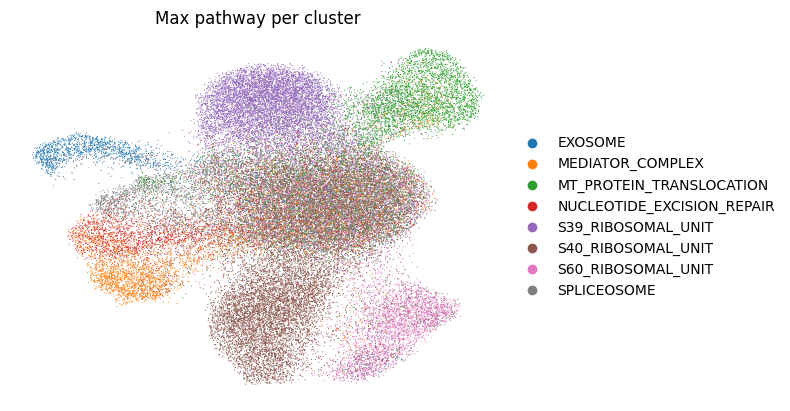

In [62]:
# bring dend_cluster onto z_sub
gene_to_cluster = perts['cluster'].astype(str)
# for each cluster, find the majority true_pathway
majority_map = (
    z_sub.obs.groupby('dend_cluster')['true_pathway']
    .agg(lambda x: x.value_counts().idxmax())
)

z_sub.obs['max_path'] = z_sub.obs['dend_cluster'].map(majority_map)

sc.pl.umap(z_sub, color='max_path', frameon=False, title='Max pathway per cluster')


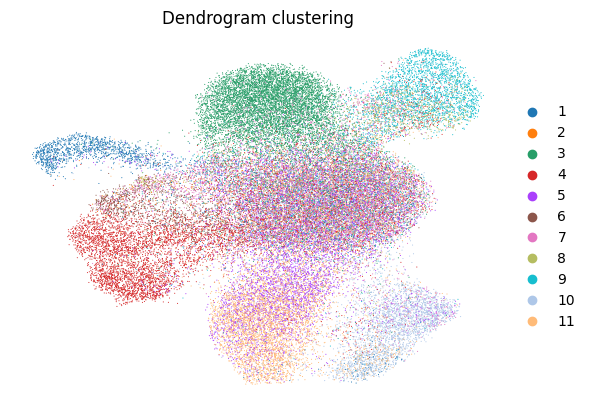

In [63]:
gene_to_cluster = perts['cluster'].astype(str)
z_sub.obs['dend_cluster'] = z_sub.obs[p_key].map(gene_to_cluster)

sc.pl.umap(z_sub, color='dend_cluster', frameon=False, title='Dendrogram clustering')

In [64]:
ev_df = slk.pl.make_ev_long_df(data)


merged = results["merged"].copy()

path_map = merged[["gene", "pathway", "mapped_pathway", "is_match"]].rename(
    columns={"gene": "pert"}
)

ev_annot = ev_df.merge(path_map, on="pert", how="inner")

ev_annot["pathway_used"] = ev_annot["mapped_pathway"].astype(str)

alpha = 0.05
ev_sig = ev_annot[ev_annot["qval"] < alpha].copy()
if ev_sig.empty:
    print(f"No significant (pert, gene) pairs at q < {alpha}.")
else:
    gp = ev_sig.groupby(["pathway_used", "gene"])
    pathway_targets = (
        gp.agg(
            n_perts=("pert", "nunique"),
            mean_ev=("ev", "mean"),
            mean_qval=("qval", "mean"),
        )
        .reset_index()
        .rename(columns={"pathway_used": "pathway", "gene": "target_gene"})
        .sort_values(["pathway", "mean_qval", "target_gene"])
    )
    print(
        pathway_targets
    )

          pathway target_gene  n_perts   mean_ev      mean_qval
666       EXOSOME     THUMPD1        1  0.039532  1.601351e-299
4         EXOSOME  AC079466.1        4  0.021312  1.677632e-299
725       EXOSOME        UROD        4  0.029041  1.677632e-299
734       EXOSOME        WNK1        4  0.022503  1.677632e-299
94        EXOSOME       CCND3        5  0.049188  1.750726e-299
...           ...         ...      ...       ...            ...
5353  SPLICEOSOME      YTHDF2        1  0.003963   4.790807e-02
4996  SPLICEOSOME        NME6        1  0.001603   4.797731e-02
4901  SPLICEOSOME      MAGEA6        1  0.005711   4.807542e-02
5294  SPLICEOSOME      TNRC6B        1  0.007755   4.815862e-02
4897  SPLICEOSOME       LYRM7        1  0.011459   4.897339e-02

[5373 rows x 5 columns]


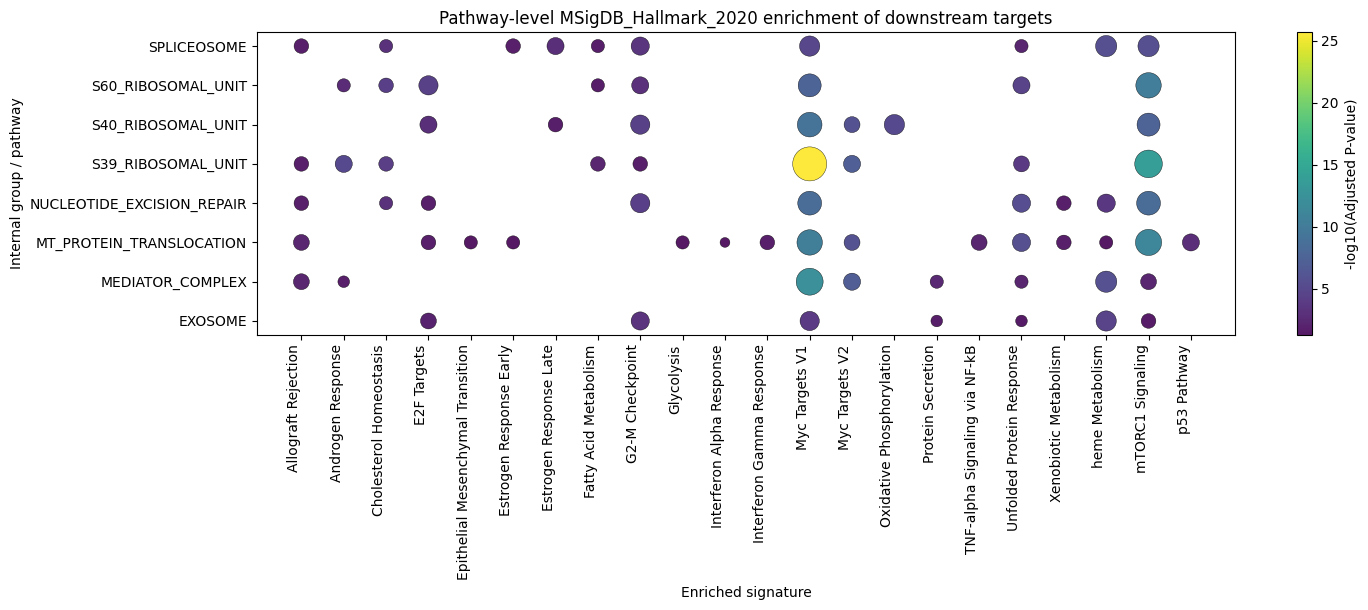

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import gseapy as gp


def run_group_enrichment_hallmark(
    pathway_targets: pd.DataFrame,
    min_genes_per_group: int = 5,
    max_genes_per_group: int = 200,
    hallmark_lib: str = "MSigDB_Oncogenic_Signatures",  # C6 here
    organism: str = "Human",
    top_terms_per_group: int = 5,
    adj_alpha: float = 0.05,   # <-- significance cutoff on Adjusted P-value
):
    """
    For each internal group/pathway, run enrichment on its target genes
    and return a tidy table of *significant* enriched terms.

    Expected columns in pathway_targets:
      - 'pathway'     : internal label (EXOSOME, SPLICEOSOME, ...)
      - 'target_gene' : gene symbol
      - (optional) 'mean_ev' : used to sort genes before truncating
    """
    df = pathway_targets.copy()

    # Drop 'None' groups if present
    df = df[df["pathway"] != "None"].copy()

    # Sort within each pathway by mean_ev if present (strongest targets first)
    if "mean_ev" in df.columns:
        df = df.sort_values(["pathway", "mean_ev"], ascending=[True, False])

    # Collect gene lists per pathway
    path_to_genes = (
        df.groupby("pathway")["target_gene"]
          .apply(lambda s: list(dict.fromkeys(s.astype(str))))  # drop dups, keep order
          .to_dict()
    )

    rows = []

    for pw, genes in path_to_genes.items():
        # Cap number of genes (to avoid huge lists)
        genes = genes[:max_genes_per_group]

        if len(genes) < min_genes_per_group:
            continue

        enr = gp.enrichr(
            gene_list=genes,
            gene_sets=[hallmark_lib],
            organism=organism,
            outdir=None,
            cutoff=1.0,  # keep all; we'll filter ourselves
        )

        res = enr.results.copy()
        if res.empty:
            continue

        res["pathway"] = pw

        # Parse overlap "k/n" -> k
        def parse_k(s):
            try:
                k, n = s.split("/")
                return int(k)
            except Exception:
                return np.nan

        res["overlap_k"] = res["Overlap"].astype(str).apply(parse_k)
        res["minus_log10_adjP"] = -np.log10(
            res["Adjusted P-value"].clip(lower=1e-300)
        )

        # === keep only significant terms ===
        res = res[res["Adjusted P-value"] <= adj_alpha]
        if res.empty:
            continue

        # Take top N significant terms by adjusted p-value
        res = res.sort_values("Adjusted P-value").head(top_terms_per_group)

        rows.append(
            res[
                ["pathway", "Term", "Adjusted P-value",
                 "Overlap", "overlap_k", "minus_log10_adjP"]
            ]
        )

    if not rows:
        raise ValueError("No significant enrichment results at adj_alpha "
                         f"= {adj_alpha}. Try relaxing the cutoff or min_genes_per_group.")

    enrich_df = pd.concat(rows, ignore_index=True)
    return enrich_df


def plot_hallmark_dotplot(enrich_df: pd.DataFrame, title: str = ""):
    """
    Dot plot:
      - y-axis: internal groups (pathway)
      - x-axis: enriched terms
      - size: number of overlapping genes (overlap_k)
      - color: -log10(adjusted p-value)
    """
    df = enrich_df.copy()

    # Categorical encodings for axes
    path_cats = pd.Categorical(df["pathway"])
    term_cats = pd.Categorical(df["Term"])

    df["y"] = path_cats.codes
    df["x"] = term_cats.codes

    # Sizes based on overlap_k
    k = df["overlap_k"].fillna(0).astype(float)
    if k.max() > 0:
        k_norm = (k - k.min()) / (k.max() - k.min() + 1e-8)
    else:
        k_norm = k
    size_min, size_max = 50, 600  # points^2
    df["dot_size"] = size_min + k_norm * (size_max - size_min)

    # Colors based on -log10(adjP)
    cvals = df["minus_log10_adjP"]
    norm = mpl.colors.Normalize(vmin=cvals.min(), vmax=cvals.max())
    cmap = plt.cm.viridis

    fig, ax = plt.subplots(
        figsize=(0.5 * len(term_cats.categories) + 4,
                 0.4 * len(path_cats.categories) + 3)
    )

    sc = ax.scatter(
        df["x"],
        df["y"],
        s=df["dot_size"],
        c=cvals,
        cmap=cmap,
        norm=norm,
        edgecolor="k",
        linewidth=0.3,
        alpha=0.9,
    )

    ax.set_xticks(np.arange(len(term_cats.categories)))
    ax.set_xticklabels(term_cats.categories, rotation=90, ha="right")

    ax.set_yticks(np.arange(len(path_cats.categories)))
    ax.set_yticklabels(path_cats.categories)

    ax.set_xlabel("Enriched signature")
    ax.set_ylabel("Internal group / pathway")

    ax.set_title(title)

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("-log10(Adjusted P-value)")

    plt.tight_layout()
    plt.show()



enrich = run_group_enrichment_hallmark(
    pathway_targets=pathway_targets,
    min_genes_per_group=5,
    max_genes_per_group=200,
    hallmark_lib="MSigDB_Hallmark_2020",
    organism="Human",
    top_terms_per_group=20,
    adj_alpha=0.05,   
)

plot_hallmark_dotplot(enrich, title="Pathway-level MSigDB_Hallmark_2020 enrichment of downstream targets")
